# Description
Run `database_prep.ipynb` before running this script.

# Imports

In [1]:
import pandas as pd
import os
import numpy as np
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import fdrcorrection


In [2]:
root_dir = "/Users/emmanuelle.coutu-nadeau/Library/Mobile Documents/com~apple~CloudDocs/UdeM/MSc Psycho/LABO NED - Personal Drive/Code/GENiAL/"
og_data = os.path.join(root_dir, 'Data/Final/GENIAL-DB-preprocessed-V2.csv') # original data
og_data = pd.read_csv(og_data)

# Data Manipulations

Make sure EEG features are numerical

In [3]:
# Make sure EEG_ columns are numeric
# Get all EEG_ columns except known non-numeric ones
non_numeric_cols = ['EEG_attempted', 'EEG_site', 'EEG_date', 'EEG_age', 'EEG_Age', 'EEG_Sex', 'Sex_at_birth', 'ParticipantID', 'Birthdate']
eeg_cols = [col for col in og_data.columns if col.startswith('EEG_') and col not in non_numeric_cols]

# Convert EEG columns to numeric, coercing errors to NaN
for col in eeg_cols:
    og_data[col] = pd.to_numeric(og_data[col], errors='coerce')


Remove over 80% EEG features issing rows

In [4]:
# Calculate the percentage of missing values for each row
missing_percentage = og_data[eeg_cols].isnull().mean(axis=1)

# Keep only rows where less than 80% of EEG features are missing
no_missing_data = og_data[missing_percentage < 0.8].reset_index(drop=True)

print(f"Rows remaining after dropping those with >80% missing EEG data: {len(no_missing_data)}")


Rows remaining after dropping those with >80% missing EEG data: 80


In [5]:
diagnostic_groups_data = no_missing_data.copy()

# Add diagnostic group column
# 0: Control (diag_control = 1)
# 1: Neurodev only (diag_neurodev = 1 and diag_genetic_carrier = 0)
# 2: Genetic carrier (diag_genetic_carrier = 1)
diagnostic_groups_data['diagnostic_group'] = 0

# Set group 1: Neurodev only
diagnostic_groups_data.loc[(diagnostic_groups_data['diag_neurodev'] == 1) & (diagnostic_groups_data['diag_genetic_carrier'] == 0), 'diagnostic_group'] = 1

# Set group 2: Genetic carrier
diagnostic_groups_data.loc[diagnostic_groups_data['diag_genetic_carrier'] == 1, 'diagnostic_group'] = 2


In [6]:
# Drop EEG_Age and EEG_Sex columns
diagnostic_groups_data = diagnostic_groups_data.drop(['EEG_Age', 'EEG_Sex'], axis=1)


# Stats

Summarize data

In [7]:
# Get summary statistics for EEG columns
eeg_summary = diagnostic_groups_data[eeg_cols].agg(['min', 'max', 'mean']).round(2)

# Display summary
print("\nEEG Features Summary:")
print(eeg_summary)



EEG Features Summary:
      EEG_Exponent-Frontal  EEG_Exponent-Central  EEG_Exponent-temporal-r  \
min                   0.54                  0.63                     0.52   
max                   1.98                  2.04                     1.99   
mean                  1.35                  1.40                     1.30   

      EEG_Exponent-temporal-l  EEG_Exponent-parietal-r  \
min                      0.31                     0.53   
max                      1.99                     1.98   
mean                     1.33                     1.33   

      EEG_Exponent-parietal-l  EEG_Exponent-Occipital  \
min                      0.27                    0.63   
max                      1.91                    2.04   
mean                     1.32                    1.46   

      EEG_Exponent-WholeBrain  EEG_Offset-Frontal  EEG_Offset-Central  ...  \
min                      0.66                0.15               -0.48  ...   
max                      1.94                2.26 

In [8]:
# Calculate z-scores for each EEG feature within each diagnostic group
z_scores = pd.DataFrame()

for group in diagnostic_groups_data['diagnostic_group'].unique():
    group_data = diagnostic_groups_data[diagnostic_groups_data['diagnostic_group'] == group]
    
    # Calculate z-scores for all EEG columns in this group
    group_z_scores = group_data[eeg_cols].apply(lambda x: (x - x.mean()) / x.std())
    
    # Add group identifier
    group_z_scores['diagnostic_group'] = group
    
    # Append to main z-scores dataframe
    z_scores = pd.concat([z_scores, group_z_scores])

# Reset index of final dataframe
z_scores = z_scores.reset_index(drop=True)

print("\nZ-scores calculated for each diagnostic group")
print(f"Shape of z-scores dataframe: {z_scores.shape}")




Z-scores calculated for each diagnostic group
Shape of z-scores dataframe: (80, 177)


In [9]:
# Check for extreme z-scores (|z| > 3.29)
extreme_mask = (z_scores[eeg_cols].abs() > 3.29)
num_extreme = extreme_mask.sum()

print("\nNumber of extreme z-scores (|z| > 3.29) for each EEG feature:")
print(num_extreme)

# Get columns with extreme scores
columns_with_extremes = [col for col, count in num_extreme.items() if count > 0]
print("\nColumns with extreme scores:")
print(columns_with_extremes)

total_extreme_rows = extreme_mask.any(axis=1).sum()

if total_extreme_rows > 0:
    print(f"\nFound {total_extreme_rows} rows with extreme z-scores")
    print("\nBreakdown by diagnostic group:")
    for group in [0, 1, 2]:
        group_rows = extreme_mask[z_scores['diagnostic_group'] == group].any(axis=1).sum()
        group_name = {
            0: "Control",
            1: "Neurodev only", 
            2: "Genetic carrier"
        }[group]
        print(f"{group_name}: {group_rows} rows with extreme values")
else:
    print("\nNo extreme z-scores found.")



Number of extreme z-scores (|z| > 3.29) for each EEG feature:
EEG_Exponent-Frontal       0
EEG_Exponent-Central       0
EEG_Exponent-temporal-r    0
EEG_Exponent-temporal-l    0
EEG_Exponent-parietal-r    0
                          ..
EEG_DFA-Beta_temporal-l    0
EEG_DFA-Beta_parietal-r    0
EEG_DFA-Beta_parietal-l    0
EEG_DFA-Beta_Occipital     0
EEG_DFA-Beta_WholeBrain    0
Length: 176, dtype: int64

Columns with extreme scores:
['EEG_Delta-Frontal', 'EEG_Delta-temporal-r', 'EEG_Delta-temporal-l', 'EEG_Delta-parietal-r', 'EEG_Delta-parietal-l', 'EEG_Delta-Occipital', 'EEG_Theta-Frontal', 'EEG_Theta-Central', 'EEG_Theta-temporal-r', 'EEG_Theta-temporal-l', 'EEG_Theta-parietal-r', 'EEG_Theta-parietal-l', 'EEG_Theta-Occipital', 'EEG_Theta-WholeBrain', 'EEG_Alpha-Central', 'EEG_Alpha-temporal-r', 'EEG_Alpha-temporal-l', 'EEG_Alpha-parietal-r', 'EEG_Alpha-parietal-l', 'EEG_Alpha-Occipital', 'EEG_Alpha-WholeBrain', 'EEG_Beta-Frontal', 'EEG_Beta-temporal-l', 'EEG_Beta-parietal-r', 'EEG_B

Adjust extreme scores (Z > 3.29)

In [10]:
def adjust_extreme_scores(db, colname):
    # Convert list to array if needed
    if isinstance(db[colname], list):
        db[colname] = np.array(db[colname])
    
    # Convert to numeric
    db[colname] = pd.to_numeric(db[colname])
    
    # Calculate min/max thresholds
    mean = np.nanmean(db[colname])
    std = np.nanstd(db[colname])
    min_val = mean - (3.29 * std)
    max_val = mean + (3.29 * std)
    
    # Replace extreme scores
    db[colname] = np.where(
        pd.isna(db[colname]), 
        np.nan,
        np.where(
            db[colname] < min_val,
            min_val,
            np.where(
                db[colname] > max_val,
                max_val,
                db[colname]
            )
        )
    )
    
    return db

In [27]:
df = diagnostic_groups_data.copy()

# Adjust extreme scores for each column with extreme z-scores
for col in columns_with_extremes:
    df = adjust_extreme_scores(df, col)

Descriptive stats

In [28]:
# Get numeric columns but exclude binary diagnostic columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
numeric_cols = [col for col in numeric_cols if not col.startswith('diag_') 
                and not col.startswith('inheritance_') 
                and col != ('diagnostic_group')
                and col != ('EEG_attempted')
                and col != ('EEG_site')
                and col != ('EEG_date')]
descriptive_stats = df[numeric_cols].describe()

# Add skewness and kurtosis
descriptive_stats.loc['skew'] = df[numeric_cols].skew()
descriptive_stats.loc['kurtosis'] = df[numeric_cols].kurtosis()

# # Display the descriptive statistics
# print("\nDescriptive Statistics:")
# print(descriptive_stats)

# Get descriptive statistics for EEG_age by diagnostic group
age_stats = df.groupby('diagnostic_group')['EEG_age'].describe()
age_stats.index = ['Control', 'Neurodevelopmental', 'Genetic Carrier']

# Get sex counts by diagnostic group
sex_counts = pd.crosstab(df['diagnostic_group'], df['Sex_at_birth'])
sex_counts.index = ['Control', 'Neurodevelopmental', 'Genetic Carrier']

print("\nEEG Age Statistics by Group:")
print("-" * 50)
print(age_stats)

print("\nSex Distribution by Group:")
print("-" * 50)
print(sex_counts)




EEG Age Statistics by Group:
--------------------------------------------------
                    count       mean        std       min        25%  \
Control              27.0  35.712127  14.337611  4.281972  32.915061   
Neurodevelopmental   28.0  24.561527  14.789893  8.202655  11.851715   
Genetic Carrier      25.0  18.122959  15.460302  2.981581   6.921429   

                          50%        75%        max  
Control             40.167834  43.906389  57.071557  
Neurodevelopmental  14.718988  38.056907  55.270015  
Genetic Carrier      9.259601  34.218362  58.133865  

Sex Distribution by Group:
--------------------------------------------------
Sex_at_birth        Female  Male
Control                 17    10
Neurodevelopmental      16    12
Genetic Carrier         12    13


### ANCOVA

In [21]:
# Prepare data for analysis
# Get all EEG columns except EEG_Sex and EEG_Age
eeg_cols = [col for col in df.columns if col.startswith('EEG_') 
            and col not in ['EEG_attempted', 'EEG_site', 'EEG_date']]

# Define diagnostic groups
diagnostic_groups = [0, 1, 2]  # 0=control, 1=neurodev, 2=genetic carrier
group_labels = ['Control', 'Neurodevelopmental', 'Genetic Carrier']

# Convert Sex_at_birth to numeric (0=Male, 1=Female)
df['Sex_at_birth'] = (df['Sex_at_birth'] == 'Female').astype(int)

# Convert EEG columns to numeric type and handle any string values
for col in eeg_cols:
    # Replace any non-numeric values with NaN and convert to float64
    df[col] = pd.to_numeric(df[col].replace(['', 'NA', 'nan'], np.nan), errors='coerce').astype('float64')
    
    # Print number of valid values to verify data
    valid_count = df[col].notna().sum()
    print(f"{col}: {valid_count} valid numeric values")

# Perform ANCOVA for each EEG feature
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
anova_results = {}

print("\nANCOVA Results:")
print("-" * 50)

for eeg_feature in eeg_cols:
    print(f"\nAnalyzing {eeg_feature}")
    
    # Create DataFrame for analysis with complete cases only
    analysis_df = df[[eeg_feature, 'diagnostic_group', 'Sex_at_birth', 'EEG_age']].dropna()
    
    # Ensure numeric type for the EEG feature
    analysis_df[eeg_feature] = analysis_df[eeg_feature].astype('float64')
    
    # Print group sizes
    for group, label in zip(diagnostic_groups, group_labels):
        group_size = len(analysis_df[analysis_df['diagnostic_group'] == group])
        print(f"{label} group size: {group_size}")
    
    # Skip if any group has no data
    if any(len(analysis_df[analysis_df['diagnostic_group'] == group]) == 0 for group in diagnostic_groups):
        print(f"Skipping {eeg_feature} - insufficient data in one or more groups")
        continue
        
    try:
        # Create dummy variables for diagnostic group
        diagnostic_dummies = pd.get_dummies(analysis_df['diagnostic_group'], prefix='group')
        
        # Prepare model matrix
        X = pd.concat([
            diagnostic_dummies.iloc[:, 1:],  # Exclude one group as reference
            analysis_df[['Sex_at_birth', 'EEG_age']]
        ], axis=1)
        
        # Ensure all data is numeric
        y = analysis_df[eeg_feature].astype('float64')
        X = X.astype('float64')
        
        # Fit ANCOVA model
        model = sm.OLS(y, sm.add_constant(X))
        results = model.fit()
        
        # Store results
        anova_results[eeg_feature] = {
            'F-statistic': results.fvalue,
            'p-value': results.f_pvalue
        }
        
        # Print results
        print(f"\nFeature: {eeg_feature}")
        print(f"F-statistic: {results.fvalue:.4f}")
        print(f"p-value: {results.f_pvalue:.4f}")
        print("\nDetailed Results:")
        print(results.summary().tables[1])
        
        # If significant main effect, perform post-hoc tests
        if results.f_pvalue < 0.05:
            print("\nPost-hoc t-tests (not accounting for covariates):")
            for i, (group1, label1) in enumerate(zip(diagnostic_groups, group_labels)):
                for group2, label2 in zip(diagnostic_groups[i+1:], group_labels[i+1:]):
                    group1_data = analysis_df[analysis_df['diagnostic_group'] == group1][eeg_feature]
                    group2_data = analysis_df[analysis_df['diagnostic_group'] == group2][eeg_feature]
                    
                    if len(group1_data) > 0 and len(group2_data) > 0:
                        t_stat, t_pval = stats.ttest_ind(group1_data, group2_data)
                        print(f"{label1} vs {label2}:")
                        print(f"t-statistic: {t_stat:.4f}")
                        print(f"p-value: {t_pval:.4f}")
                    else:
                        print(f"Skipping {label1} vs {label2} - insufficient data")
                        
    except Exception as e:
        print(f"\nError analyzing {eeg_feature}: {str(e)}")

# Export ANOVA results to text file
with open('anova_results.txt', 'w') as f:
    f.write("ANOVA Results Summary\n")
    f.write("====================\n\n")
    
    for eeg_feature in anova_results:
        f.write(f"\nFeature: {eeg_feature}\n")
        f.write(f"F-statistic: {anova_results[eeg_feature]['F-statistic']:.4f}\n")
        f.write(f"p-value: {anova_results[eeg_feature]['p-value']:.4f}\n")
        
        # Add separator between features
        f.write("\n" + "-"*50 + "\n")

print("\nResults exported to 'anova_results.txt'")


EEG_age: 80 valid numeric values
EEG_Exponent-Frontal: 80 valid numeric values
EEG_Exponent-Central: 80 valid numeric values
EEG_Exponent-temporal-r: 80 valid numeric values
EEG_Exponent-temporal-l: 80 valid numeric values
EEG_Exponent-parietal-r: 80 valid numeric values
EEG_Exponent-parietal-l: 80 valid numeric values
EEG_Exponent-Occipital: 80 valid numeric values
EEG_Exponent-WholeBrain: 80 valid numeric values
EEG_Offset-Frontal: 80 valid numeric values
EEG_Offset-Central: 80 valid numeric values
EEG_Offset-temporal-r: 80 valid numeric values
EEG_Offset-temporal-l: 80 valid numeric values
EEG_Offset-parietal-r: 80 valid numeric values
EEG_Offset-parietal-l: 80 valid numeric values
EEG_Offset-Occipital: 80 valid numeric values
EEG_Offset-WholeBrain: 80 valid numeric values
EEG_Hurst-Frontal: 80 valid numeric values
EEG_Hurst-Central: 80 valid numeric values
EEG_Hurst-temporal-r: 80 valid numeric values
EEG_Hurst-temporal-l: 80 valid numeric values
EEG_Hurst-parietal-r: 80 valid nume

/Users/emmanuelle.coutu-nadeau/Library/Mobile Documents/com~apple~CloudDocs/Code/CHU/NEDLab/venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/emmanuelle.coutu-nadeau/Library/Mobile Documents/com~apple~CloudDocs/Code/CHU/NEDLab/venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/emmanuelle.coutu-nadeau/Library/Mobile Documents/com~apple~CloudDocs/Code/CHU/NEDLab/venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/emmanuelle.coutu-nadeau/Library/Mobile Documents/com~apple~CloudDocs/Code/CHU/NEDLab/venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarnin


Feature: EEG_Alpha-WholeBrain
F-statistic: 13.0680
p-value: 0.0000

Detailed Results:
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            1.8186      0.359      5.067      0.000       1.104       2.534
group_1         -0.2040      0.303     -0.673      0.503      -0.808       0.400
group_2          0.8620      0.331      2.605      0.011       0.203       1.521
Sex_at_birth          0          0        nan        nan           0           0
EEG_age         -0.0296      0.008     -3.604      0.001      -0.046      -0.013

Post-hoc t-tests (not accounting for covariates):
Control vs Neurodevelopmental:
t-statistic: -0.5584
p-value: 0.5789
Control vs Genetic Carrier:
t-statistic: -3.8351
p-value: 0.0004
Neurodevelopmental vs Genetic Carrier:
t-statistic: -3.5878
p-value: 0.0007

Analyzing EEG_Beta-Frontal
Control group size: 27
Neurodevelopmental group size: 28
G

/Users/emmanuelle.coutu-nadeau/Library/Mobile Documents/com~apple~CloudDocs/Code/CHU/NEDLab/venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/emmanuelle.coutu-nadeau/Library/Mobile Documents/com~apple~CloudDocs/Code/CHU/NEDLab/venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/emmanuelle.coutu-nadeau/Library/Mobile Documents/com~apple~CloudDocs/Code/CHU/NEDLab/venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/emmanuelle.coutu-nadeau/Library/Mobile Documents/com~apple~CloudDocs/Code/CHU/NEDLab/venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarnin


Feature: EEG_relative-LowGamma-parietal-r
F-statistic: 12.5023
p-value: 0.0000

Detailed Results:
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0004      0.003     -0.123      0.903      -0.007       0.006
group_1          0.0071      0.003      2.504      0.014       0.001       0.013
group_2          0.0005      0.003      0.150      0.881      -0.006       0.007
Sex_at_birth          0          0        nan        nan           0           0
EEG_age          0.0004   7.67e-05      5.101      0.000       0.000       0.001

Post-hoc t-tests (not accounting for covariates):
Control vs Neurodevelopmental:
t-statistic: -0.7621
p-value: 0.4494
Control vs Genetic Carrier:
t-statistic: 2.4731
p-value: 0.0168
Neurodevelopmental vs Genetic Carrier:
t-statistic: 2.8892
p-value: 0.0057

Analyzing EEG_relative-LowGamma-parietal-l
Control group size: 27
Neurodeve

/Users/emmanuelle.coutu-nadeau/Library/Mobile Documents/com~apple~CloudDocs/Code/CHU/NEDLab/venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/emmanuelle.coutu-nadeau/Library/Mobile Documents/com~apple~CloudDocs/Code/CHU/NEDLab/venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/emmanuelle.coutu-nadeau/Library/Mobile Documents/com~apple~CloudDocs/Code/CHU/NEDLab/venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/emmanuelle.coutu-nadeau/Library/Mobile Documents/com~apple~CloudDocs/Code/CHU/NEDLab/venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarnin


Feature: EEG_DFA-Beta_parietal-l
F-statistic: 1.7727
p-value: 0.1595

Detailed Results:
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.6347      0.019     33.251      0.000       0.597       0.673
group_1         -0.0063      0.016     -0.390      0.697      -0.038       0.026
group_2          0.0273      0.018      1.553      0.125      -0.008       0.062
Sex_at_birth          0          0        nan        nan           0           0
EEG_age      -6.125e-05      0.000     -0.140      0.889      -0.001       0.001

Analyzing EEG_DFA-Beta_Occipital
Control group size: 27
Neurodevelopmental group size: 28
Genetic Carrier group size: 25

Feature: EEG_DFA-Beta_Occipital
F-statistic: 3.7782
p-value: 0.0139

Detailed Results:
                   coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------

In [23]:
anova_df = pd.DataFrame(anova_results).T  # Transpose to make features as rows
anova_df.sort_values('p-value', inplace=True)

# --- Filter significant features ---
signif_features = anova_df[anova_df['p-value'] < 0.05].index.tolist()

# --- Run Tukey HSD for each significant feature ---
for feature in signif_features:
    print(f"\n📊 Tukey HSD for: {feature}")
    tukey = pairwise_tukeyhsd(endog=df[feature], groups=df['diagnostic_group'], alpha=0.05)
    print(tukey.summary())

# Save Tukey HSD results to text file
with open('tukey_results.txt', 'w') as f:
    f.write("Tukey HSD Results Summary\n")
    f.write("=======================\n\n")
    
    for feature in signif_features:
        f.write(f"\nFeature: {feature}\n")
        f.write("-------------------\n")
        tukey = pairwise_tukeyhsd(endog=df[feature], groups=df['diagnostic_group'], alpha=0.05)
        f.write(tukey.summary().as_text())
        f.write("\n" + "="*50 + "\n")

print("\nTukey HSD results exported to 'tukey_results.txt'")



📊 Tukey HSD for: EEG_Offset-temporal-l
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower  upper  reject
--------------------------------------------------
     0      1   0.1018 0.7353 -0.223 0.4266  False
     0      2    0.491 0.0021 0.1568 0.8253   True
     1      2   0.3893 0.0172 0.0579 0.7206   True
--------------------------------------------------

📊 Tukey HSD for: EEG_Offset-temporal-r
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     0      1   0.0599 0.8886 -0.2489 0.3686  False
     0      2   0.5309 0.0004  0.2132 0.8487   True
     1      2   0.4711 0.0017  0.1561 0.7861   True
---------------------------------------------------

📊 Tukey HSD for: EEG_Offset-Central
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     

#### Visualize

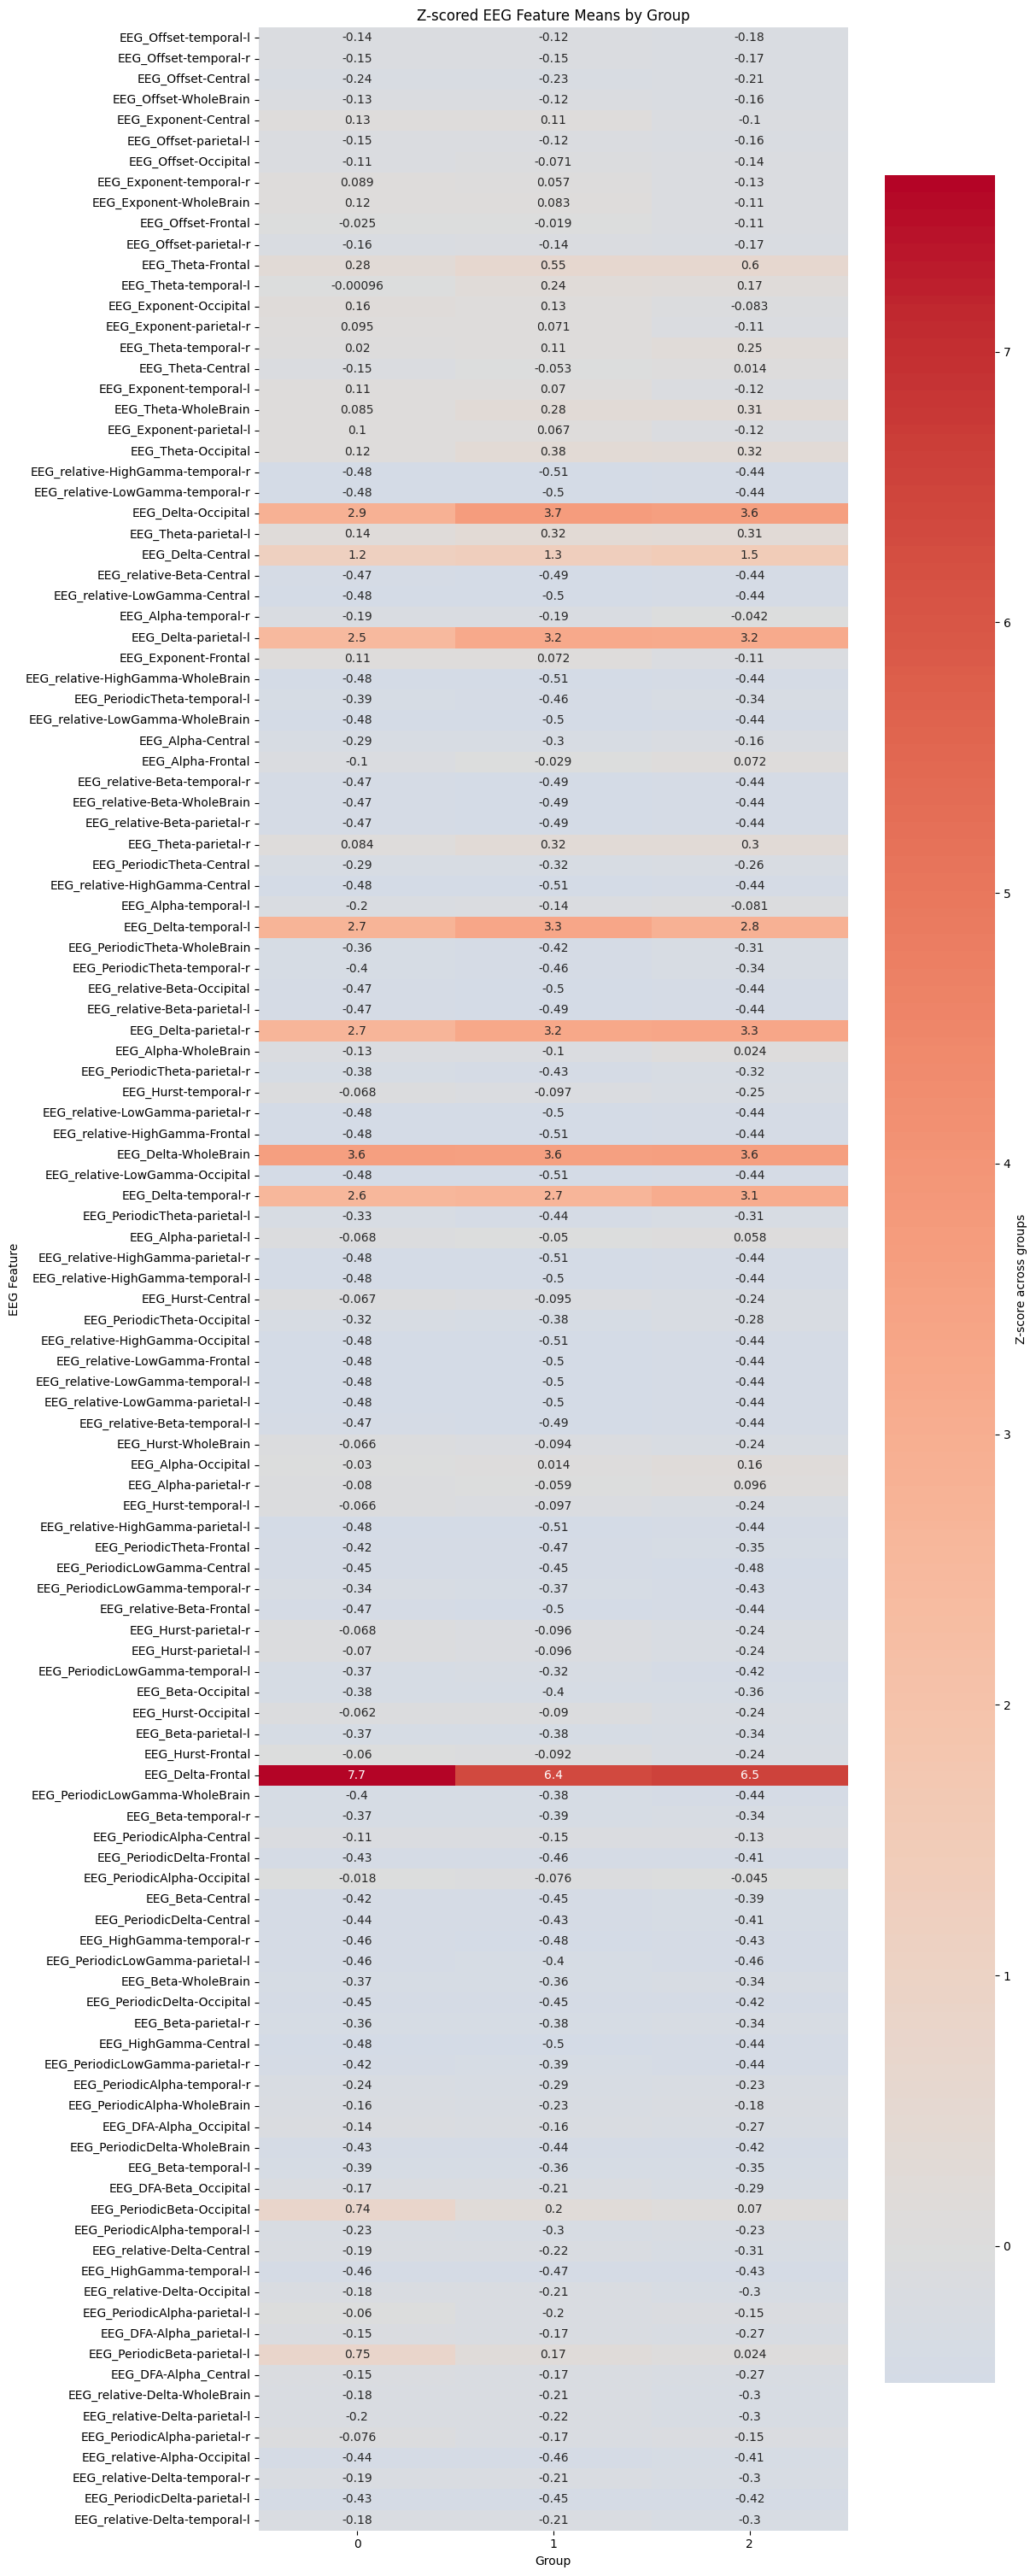

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Compute group means for significant features only
group_col = 'diagnostic_group'
features_to_plot = signif_features  # from your ANOVA results

group_means = df.groupby(group_col)[features_to_plot].mean()

# 2. Optional: Z-score features across groups (row-wise)
# This helps with visual contrast
scaler = StandardScaler()
group_means_z = pd.DataFrame(
    scaler.fit_transform(group_means.T),
    index=group_means.columns,
    columns=group_means.index
)

# 3. Plot heatmap
plt.figure(figsize=(12, max(6, len(features_to_plot) * 0.25)))  # adapt size
sns.heatmap(group_means_z, annot=True, cmap='coolwarm', center=0,
            cbar_kws={'label': 'Z-score across groups'})
plt.title('Z-scored EEG Feature Means by Group')
plt.xlabel('Group')
plt.ylabel('EEG Feature')
plt.tight_layout()
plt.show()


✅ 1. Age & Sex effects are now controlled

✅ 2. Delta power dominates
EEG_Delta-Frontal, EEG_Delta-temporal-l, EEG_Delta-parietal-l, EEG_Delta-Occipital:
    🔴 Stronger in Group 2 (neurodev + genetic)
    ⚪️ High in Group 1
    🔵 Lowest in Group 0 (control)

    -> Interpretation: Elevated delta = a robust marker of neurodevelopmental pathology, even after adjusting for age and sex.

✅ 3. Gamma and periodicity reduced in ND groups
EEG_relative-HighGamma, EEG_relative-LowGamma, EEG_PeriodicTheta, etc.
    🔵 Control group shows consistently higher values
    🔴 Neurodev groups (especially 2) show lower Z-scores

    -> Interpretation: Suggests reduced spectral differentiation / higher neural noise in neurodev groups remains a strong pattern, even independent of age.

Strongest group differences cluster in:

    Frontal Delta
    Occipital/Parietal Delta
    Low/High Gamma
    Periodicity features (1/f, offset, etc.)

**Summary**  
After adjusting for _age_ and _sex_, *EEG spectral features* continue to show distinct group-level differences.   
- *Delta power* remains *elevated in neurodevelopmental* participants, particularly in frontal and parietal regions, with the *strongest increase in genetic carriers*. 
- In contrast, *controls* maintain *higher levels of gamma* activity and spectral periodicity, suggesting preserved cortical organization.


### Multiple Regression

In [ ]:
# Multiple regression for each EEG feature
import statsmodels.api as sm

print("\nMultiple Regression Results:")
print("-" * 50)

# Create dummy variables for diagnostic groups
diagnostic_dummies = pd.get_dummies(df['diagnostic_group'], prefix='group')

for eeg_feature in eeg_cols:
    try:
        # Prepare X (predictors) and y (dependent variable)
        X = diagnostic_dummies
        y = pd.to_numeric(df[eeg_feature], errors='coerce')
        
        # Remove rows with NaN values
        mask = ~y.isna()
        X = X[mask]
        y = y[mask]
        
        if len(y) == 0:
            print(f"\nSkipping regression for {eeg_feature} - no valid data")
            continue
            
        # Add constant
        X = sm.add_constant(X)
        
        # Fit model
        model = sm.OLS(y, X).fit()
        
        # Print results
        print(f"\nDependent Variable: {eeg_feature}")
        print(model.summary().tables[1])
        
    except Exception as e:
        print(f"\nError in regression for {eeg_feature}: {str(e)}")
